In [ ]:
#Telecom SLA Analysis

In [ ]:
# Step 1
import sys
!{sys.executable} -m pip install mysql-connector-python

In [10]:
# 2 - INSTALL LIBRARIES & CONNECT TO MYSQL

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import warnings
warnings.filterwarnings('ignore')
plt.style.use('dark_background')

conn = mysql.connector.connect(
    host='localhost', user='root', password='naived15', database='telecom_sla'
)
print("Connected successfully!")

Connected successfully!


In [14]:
# 3 - LOAD & MERGE THE CLEAN TABLES

complaints = pd.read_sql('SELECT * FROM complaints', conn)
assignments = pd.read_sql('SELECT * FROM assignments', conn)
engineers = pd.read_sql('SELECT * FROM engineers', conn)
customers = pd.read_sql('SELECT * FROM customers', conn)
sla_targets = pd.read_sql('SELECT * FROM sla_targets', conn)
df = (complaints
.merge(assignments, on='complaint_id')
.merge(sla_targets, on=['complaint_type', 'severity'])
.merge(engineers, on='engineer_id', how='left', suffixes=('', '_engineer')))
print(f'Merged dataset: {len(df)} rows')
print(df.dtypes)

Merged dataset: 104550 rows
complaint_id                object
customer_id                 object
region                      object
complaint_type              object
severity                    object
fault_location              object
created_at          datetime64[ns]
engineer_id                 object
assigned_at         datetime64[ns]
resolved_at         datetime64[ns]
duration_suspect             int64
target_hours                 int64
name                        object
region_engineer             object
skill_type                  object
dtype: object


In [16]:
# 4 - VALIDATE THE CLEAN DATA

print(df.isnull().sum())
print('Duplicate complaint_id:', df['complaint_id'].duplicated().sum())
print('Date range:', df['created_at'].min(), 'to', df['created_at'].max())

complaint_id           0
customer_id            0
region                 0
complaint_type         0
severity               0
fault_location         0
created_at             0
engineer_id         1612
assigned_at         1612
resolved_at         4132
duration_suspect       0
target_hours           0
name                1612
region_engineer     1612
skill_type          1612
dtype: int64
Duplicate complaint_id: 0
Date range: 2025-01-01 00:00:31 to 2026-06-22 23:57:47


In [18]:
# 5- COMPUTE BREACH FLAG & MTTR
resolved = df[(df['duration_suspect'] == 0) & df['resolved_at'].notna()].copy()
resolved['mttr_hours'] = (resolved['resolved_at'] -
resolved['assigned_at']).dt.total_seconds() / 3600
resolved['breached'] = resolved['mttr_hours'] > resolved['target_hours']
print(f"Overall SLA compliance: {(1 - resolved['breached'].mean())*100:.1f}%")
print(resolved.groupby('complaint_type')['breached'].mean().sort_values(ascending=False))
print(resolved.groupby('region')['breached'].mean().sort_values(ascending=False))

Overall SLA compliance: 76.3%
complaint_type
Network    0.402278
Service    0.161809
Device     0.125476
Billing    0.083676
Name: breached, dtype: float64
region
Mumbai       0.384078
Chennai      0.362029
Delhi        0.237016
Bangalore    0.218024
Kolkata      0.148071
Hyderabad    0.144436
Pune         0.128091
Ahmedabad    0.099951
Name: breached, dtype: float64


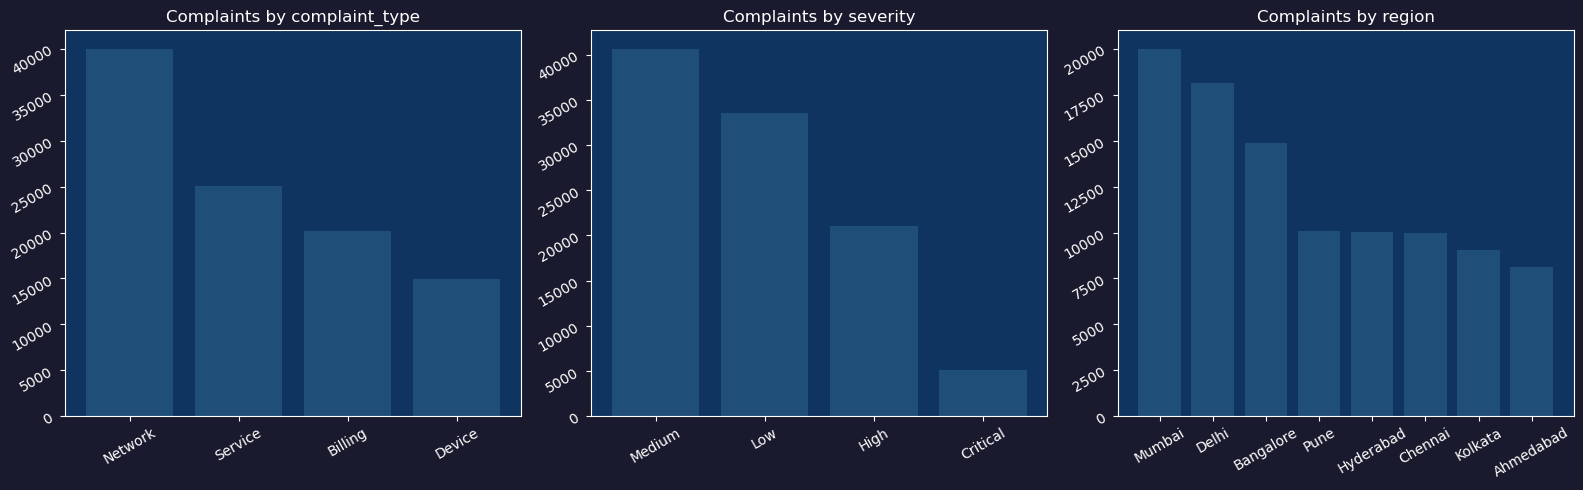

In [22]:
# 6 - EDA — DISTRIBUTIONS

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#1A1A2E')

for ax, col in zip(axes, ['complaint_type', 'severity', 'region']):
    counts = resolved[col].value_counts()
    ax.bar(counts.index, counts.values, color='#1F4E79')
    ax.set_title(f'Complaints by {col}', color='white')
    ax.tick_params(colors='white', rotation=30)
    ax.set_facecolor('#0F3460')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, facecolor='#1A1A2E')
plt.show()

In [26]:
# 7 - TRUE ROLLING 30-DAY RECURRING ROOT CAUSE

network = resolved[resolved['complaint_type'] == 'Network'].copy()
network = network[network['fault_location'] != 'UNKNOWN'].sort_values('created_at')

def flag_recurring(group):
    group = group.sort_values('created_at')
    counts = group.rolling('30D', on='created_at')['complaint_id'].count()
    group['recurring_flag'] = counts >= 3
    return group

network = network.groupby('fault_location', group_keys=False).apply(flag_recurring)

hotspot_summary = (network[network['recurring_flag']]
                    .groupby('fault_location')
                    .agg(flagged_complaints=('complaint_id', 'count'), 
                         breach_rate=('breached', 'mean'))
                    .sort_values('flagged_complaints', ascending=False))

print(hotspot_summary.head(15))
hotspot_summary.to_csv('root_cause_summary.csv')


                flagged_complaints  breach_rate
fault_location                                 
TWR-MUM-023                   1185     0.775527
TWR-MUM-012                   1170     0.767521
TWR-MUM-016                   1162     0.790017
TWR-DEL-001                   1093     0.619396
TWR-DEL-010                   1078     0.604824
TWR-DEL-025                   1071     0.625584
TWR-BAN-025                    876     0.600457
TWR-BAN-006                    860     0.575581
TWR-BAN-007                    816     0.589461
TWR-CHE-009                    666     0.777778
TWR-PUN-011                    613     0.412724
TWR-HYD-014                    593     0.453626
TWR-PUN-009                    592     0.400338
TWR-PUN-020                    578     0.401384
TWR-HYD-005                    570     0.433333


In [34]:
# 8- ENGINEER UTILISATION & SKILL-MISMATCH ANALYSIS

util = (resolved.groupby(['region', 'engineer_id'])
.size().reset_index(name='ticket_count'))
util['utilisation_index'] = util['ticket_count'] 
util.groupby('region')['ticket_count'].transform('mean')
util = util.sort_values('utilisation_index', ascending=False)
mismatch_rate = (resolved['skill_type'] != resolved['complaint_type']).mean()
print(f'Skill-mismatch rate: {mismatch_rate*100:.1f}%')
util.to_csv('engineer_utilisation.csv', index=False)

Skill-mismatch rate: 13.3%


In [36]:
# 9- REPEAT-COMPLAINT DETECTION

comp = resolved[resolved['customer_id'] != 'UNKNOWN'].sort_values('created_at')
comp['prior_same_type'] = (
comp.groupby(['customer_id', 'complaint_type'])['created_at']
.diff().dt.days.le(90)
)
repeat_rate = comp['prior_same_type'].mean()
print(f'Repeat-complaint rate (90-day, same type): {repeat_rate*100:.1f}%')

Repeat-complaint rate (90-day, same type): 10.9%


In [38]:
# 10- BREACH-RISK MODEL (LOGISTIC REGRESSION)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
features = pd.get_dummies(
resolved[['complaint_type', 'severity', 'region']], drop_first=True
)
target = resolved['breached'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
features, target, test_size=0.2, random_state=42
)
model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
preds = model.predict(X_test)
print(classification_report(y_test, preds))
coef = pd.Series(model.coef_[0], index=features.columns).sort_values(ascending=False)
print('Top breach-risk factors:')
print(coef.head(8))

              precision    recall  f1-score   support

           0       0.81      0.94      0.87     15341
           1       0.59      0.30      0.40      4725

    accuracy                           0.79     20066
   macro avg       0.70      0.62      0.63     20066
weighted avg       0.76      0.79      0.76     20066

Top breach-risk factors:
complaint_type_Network    2.106685
region_Mumbai             1.904676
region_Chennai            1.786118
region_Delhi              1.108203
region_Bangalore          0.984383
complaint_type_Service    0.757508
region_Hyderabad          0.454309
region_Kolkata            0.446524
dtype: float64


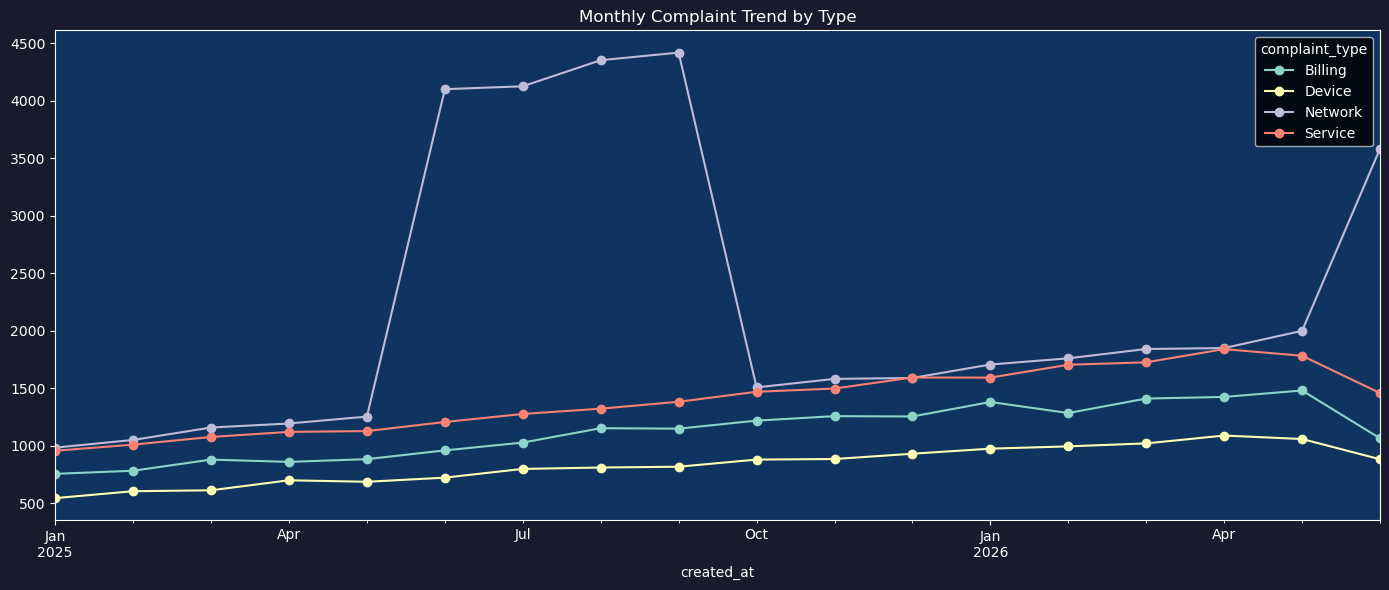

In [64]:
# 11 - VISUALISATION 1 — MONTHLY COMPLAINT TREND

trend = resolved.groupby([resolved['created_at'].dt.to_period('M'),
'complaint_type']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#1A1A2E'); ax.set_facecolor('#0F3460')
trend.plot(ax=ax, marker='o')
ax.set_title('Monthly Complaint Trend by Type', color='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig('viz1_trend.png', dpi=150, facecolor='#1A1A2E')
plt.show()

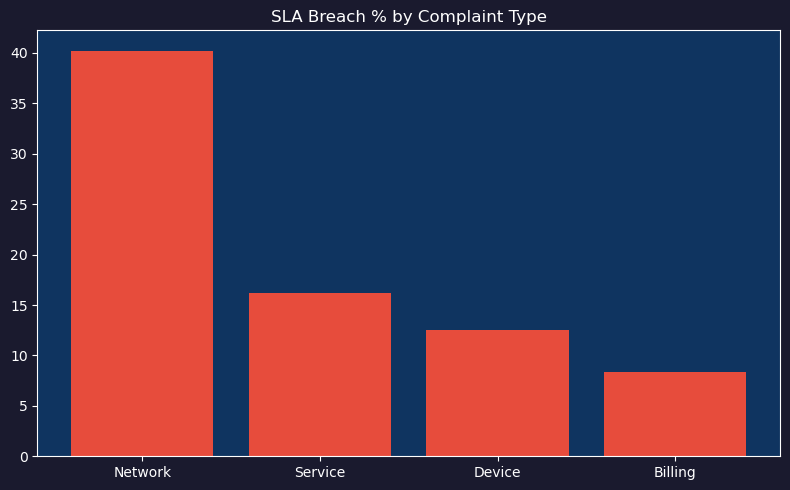

In [68]:
# 12 - VISUALISATION 2 — SLA BREACH % BY COMPLAINT TYPE

breach_type = resolved.groupby('complaint_type')['breached'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#1A1A2E')
ax.set_facecolor('#0F3460')
ax.bar(breach_type.index, breach_type.values, color='#E74C3C')
ax.set_title('SLA Breach % by Complaint Type', color='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig('viz2_breach_by_type.png', dpi=150, facecolor='#1A1A2E')
plt.show()

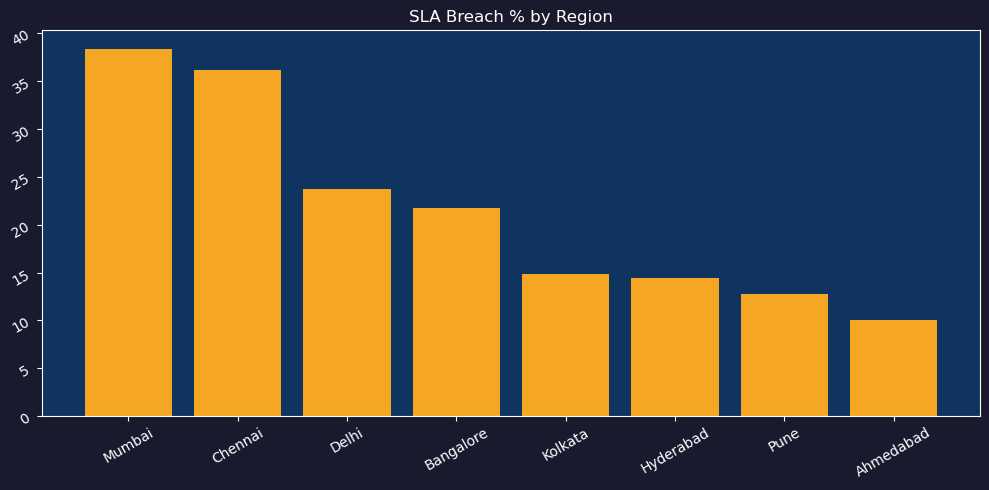

In [72]:
# 13 - VISUALISATION 3 — SLA BREACH % BY REGION

breach_region = resolved.groupby('region')['breached'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#1A1A2E')
ax.set_facecolor('#0F3460')
ax.bar(breach_region.index, breach_region.values, color='#F5A623')
ax.set_title('SLA Breach % by Region', color='white')
ax.tick_params(colors='white', rotation=30)
plt.tight_layout()
plt.savefig('viz3_breach_by_region.png', dpi=150, facecolor='#1A1A2E')
plt.show()

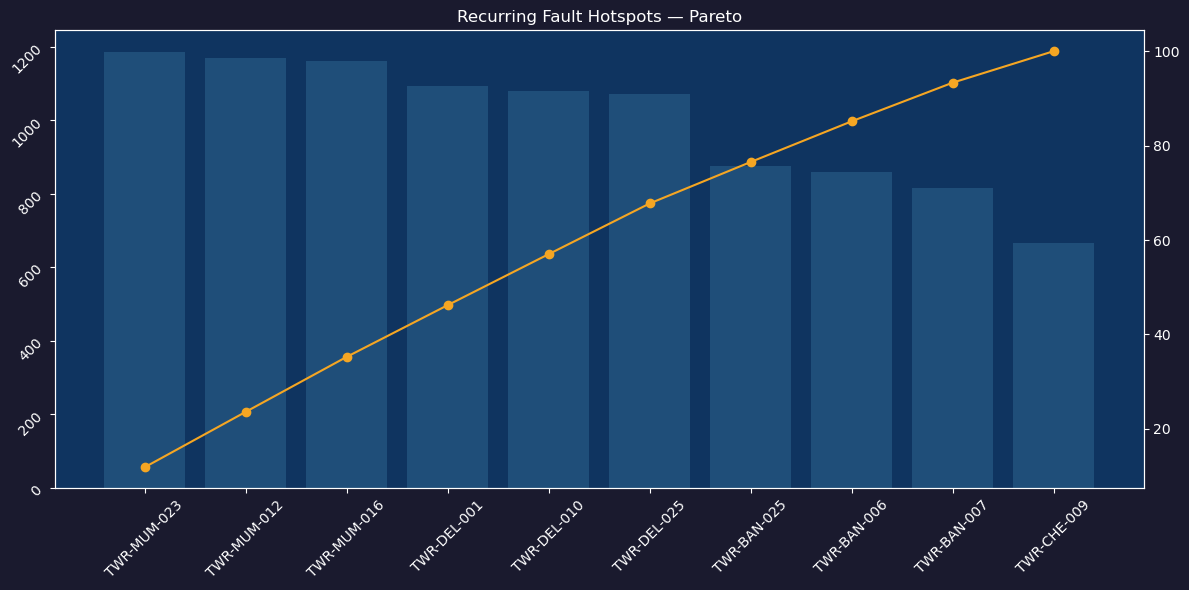

In [74]:
# 14- VISUALISATION 4 — ROOT CAUSE PARETO CHART

top = hotspot_summary.head(10).reset_index()
top['cum_pct'] = top['flagged_complaints'].cumsum() / top['flagged_complaints'].sum() * 100
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#1A1A2E'); ax1.set_facecolor('#0F3460')
ax1.bar(top['fault_location'], top['flagged_complaints'], color='#1F4E79')
ax2 = ax1.twinx()
ax2.plot(top['fault_location'], top['cum_pct'], color='#F5A623', marker='o')
ax1.set_title('Recurring Fault Hotspots — Pareto', color='white')
ax1.tick_params(colors='white', rotation=45)
ax2.tick_params(colors='white')
plt.tight_layout()
plt.savefig('viz4_root_cause_pareto.png', dpi=150, facecolor='#1A1A2E')
plt.show()

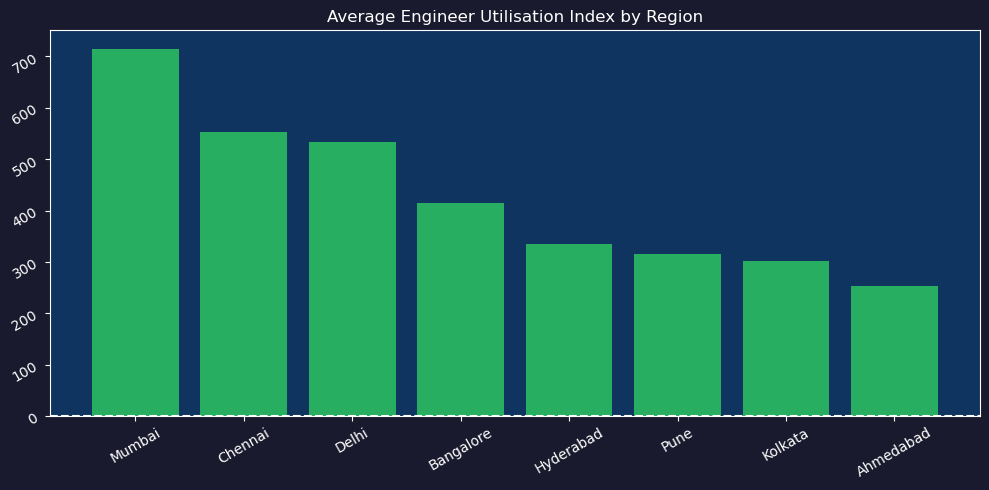

In [82]:
# 15 - VISUALISATION 5 — ENGINEER UTILISATION BY REGION

region_util = util.groupby('region')['utilisation_index'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#1A1A2E')
ax.set_facecolor('#0F3460')
ax.bar(region_util.index, region_util.values, color='#27AE60')
ax.axhline(1.0, color='white', linestyle='--')
ax.set_title('Average Engineer Utilisation Index by Region', color='white')
ax.tick_params(colors='white', rotation=30)
plt.tight_layout()
plt.savefig('viz5_engineer_utilisation.png', dpi=150, facecolor='#1A1A2E')
plt.show()

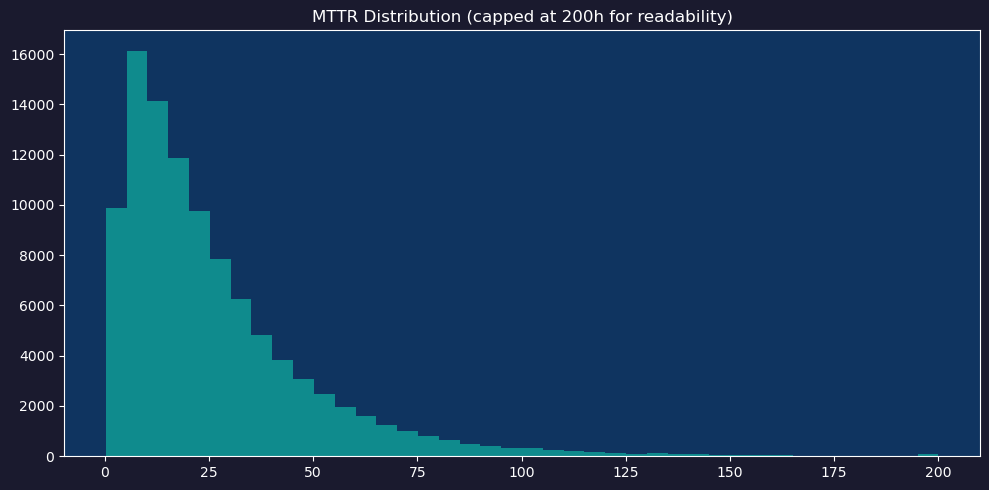

In [84]:
# 16 - VISUALISATION 6 — MTTR DISTRIBUTION

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#1A1A2E'); ax.set_facecolor('#0F3460')
ax.hist(resolved['mttr_hours'].clip(upper=200), bins=40, color='#0F8B8D')
ax.set_title('MTTR Distribution (capped at 200h for readability)', color='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig('viz6_mttr_distribution.png', dpi=150, facecolor='#1A1A2E')
plt.show()

In [86]:
# 17 - SAVE ALL OUTPUTS FOR POWER BI

resolved.to_csv('telecom_complaints_processed.csv', index=False)
hotspot_summary.to_csv('root_cause_summary.csv')
util.to_csv('engineer_utilisation.csv', index=False)
trend.to_csv('monthly_trend.csv')
print('Saved for Power BI:')
print('1. telecom_complaints_processed.csv -- row-level, with breach flag + mttr_hours')
print('2. root_cause_summary.csv -- recurring fault hotspots')
print('3. engineer_utilisation.csv -- per-engineer utilisation index')
print('4. monthly_trend.csv -- monthly complaint trend')

Saved for Power BI:
1. telecom_complaints_processed.csv -- row-level, with breach flag + mttr_hours
2. root_cause_summary.csv -- recurring fault hotspots
3. engineer_utilisation.csv -- per-engineer utilisation index
4. monthly_trend.csv -- monthly complaint trend
